# RCA4IR RAG Pipeline Demo

This notebook shows the initial FIQA RAG flow: load input records, build or reuse cached embeddings, run hybrid retrieval, and inspect the final output for root-cause-analysis style diagnostics.

In [1]:
from pathlib import Path
import sys

BACKEND_DIR = Path.cwd().parents[0] / "backend" if Path.cwd().name == "notebooks" else Path("../backend").resolve()
sys.path.insert(0, str(BACKEND_DIR))

from app.config import load_config
from app.data import load_fiqa_documents
from app.pipeline import RAGPipeline

## 1. Load Config

The YAML config starts with two candidate values for the major experimental parameters. The `active_*` values are what this run uses.

In [2]:
config = load_config(BACKEND_DIR / "config" / "rag_pipeline_config.yaml")
config.model_dump()

{'dataset': {'name': 'fiqa',
  'hf_dataset': 'explodinggradients/fiqa',
  'hf_config': 'ragas_eval',
  'hf_split': 'baseline',
  'sample_limits': [25, 100],
  'active_sample_limit': 25},
 'chunking': {'methods': ['fixed_words', 'sentence_window'],
  'active_method': 'fixed_words',
  'chunk_sizes': [120, 220],
  'active_chunk_size': 120,
  'chunk_overlaps': [20, 40],
  'active_chunk_overlap': 20},
 'embeddings': {'models': ['sklearn-hashing',
   'sentence-transformers/all-MiniLM-L6-v2'],
  'active_model': 'sklearn-hashing',
  'dimensions': {'sklearn-hashing': 384,
   'sentence-transformers/all-MiniLM-L6-v2': 384}},
 'hybrid_search': {'semantic_weights': [0.6, 0.85],
  'active_semantic_weight': 0.6,
  'keyword_weights': [0.4, 0.15],
  'active_keyword_weight': 0.4,
  'top_k_values': [3, 5],
  'active_top_k': 3},
 'answer_generation': {'methods': ['extractive', 'groq:openai/gpt-oss-20b'],
  'active_method': 'groq:openai/gpt-oss-20b'},
 'cache': {'index_dir': 'data/cache'}}

## 2. Inspect FIQA Input

If Hugging Face data is unavailable locally, the loader falls back to a tiny built-in FIQA-shaped sample so the notebook still runs.

In [3]:
documents, qa_rows = load_fiqa_documents(limit=config.dataset.active_sample_limit)
len(documents), qa_rows[:3]

/Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(25,
 [{'doc_id': 'fiqa-0',
   'question': 'How to deposit a cheque issued to an associate in my business into my business account?',
   'ground_truth': "Have the check reissued to the proper payee.Just have the associate sign the back and then deposit it.  It's called a third party cheque and is perfectly legal.  I wouldn't be surprised if it has a longer hold period and, as always, you don't get the money if the cheque doesn't clear. Now, you may have problems if it's a large amount or you're not very well known at the bank.  In that case you can have the associate go to the bank and endorse it in front of the teller with some ID.  You don't even technically have to be there.  Anybody can deposit money to your account if they have the account number. He could also just deposit it in his account and write a cheque to the business.",
   'context_count': 1},
  {'doc_id': 'fiqa-1',
   'question': 'Can I send a money order from USPS as a business?',
   'ground_truth': "Sure you can.  You 

In [4]:
documents[0].model_dump()

{'doc_id': 'fiqa-0',
 'text': 'Just have the associate sign the back and then deposit it.  It\'s called a third party cheque and is perfectly legal.  I wouldn\'t be surprised if it has a longer hold period and, as always, you don\'t get the money if the cheque doesn\'t clear. Now, you may have problems if it\'s a large amount or you\'re not very well known at the bank.  In that case you can have the associate go to the bank and endorse it in front of the teller with some ID.  You don\'t even technically have to be there.  Anybody can deposit money to your account if they have the account number. He could also just deposit it in his account and write a cheque to the business."I have checked with Bank of America, and they say the ONLY way to cash (or deposit, or otherwise get access to the funds represented by a check made out to my business) is to open a business account. They tell me this is a Federal regulation, and every bank will say the same thing.  To do this, I need a state-issue

## 3. Build or Load Cached Index

Embeddings are cached under `backend/data/cache`. Re-running with the same dataset, chunking, and embedding model should be a cache hit.

In [5]:
pipeline = RAGPipeline(config)
index_info = pipeline.build_or_load_index(force_rebuild=False)
index_info

{'config_hash': 'b81d78332e7093dbed6232829d8c8a44',
 'index_hash': 'd79ef380364cbe2189ba0387391324dd',
 'cache_hit': True,
 'chunk_count': 3,
 'embedding_shape': [3, 384],
 'cache_dir': '/Users/hanhanwu/Documents/Github/Yokan/RCA4IR/backend/data/cache'}

## 4. Query and Inspect Output

The returned chunks include combined, semantic, and keyword scores. Those fields are intended for the frontend visualizations and later RCA comparisons.

In [6]:
question = qa_rows[0]["question"] if qa_rows else "What does diversification do for a portfolio?"
result = pipeline.query(question)
result.model_dump()

{'question': 'How to deposit a cheque issued to an associate in my business into my business account?',
 'answer': 'To get that cheque into your business account you’ll need to treat it as a **third‑party cheque**:\n\n1. **Make it payable to the business** – the front of the cheque must name your company (or its DBA) as the payee.  \n2. **Get the associate’s endorsement** – the associate who issued the cheque should sign the back in the endorsement box.  \n3. **Bring identification** – you (or the associate, if required) will need to show a photo ID when you go to the bank.  \n4. **Show your business documents** – most banks will ask for proof that the deposit is for a legitimate business account, such as your EIN/Tax ID, a copy of the DBA filing, or the account‑opening paperwork.  \n5. **Deposit and be prepared for a hold** – because it’s a third‑party cheque, the bank may place a longer hold or require extra verification before the funds become available.\n\nIn short, ensure the cheq

## 5. Compare a Second Retrieval Setting

This swaps chunking and retrieval weights while reusing the same pipeline code. If the embedding/chunking settings change, a separate cache key is created.

In [7]:
variant = config.with_overrides({
    "chunking": {"active_method": "sentence_window"},
    "hybrid_search": {
        "active_semantic_weight": 0.85,
        "active_keyword_weight": 0.15,
        "active_top_k": 5,
    },
})
variant_pipeline = RAGPipeline(variant)
variant_pipeline.build_or_load_index(force_rebuild=False)
variant_result = variant_pipeline.query(question)
[
    {
        "rank": idx + 1,
        "doc_id": chunk.doc_id,
        "combined": round(chunk.score, 3),
        "semantic": round(chunk.semantic_score, 3),
        "keyword": round(chunk.keyword_score, 3),
        "preview": chunk.text[:180],
    }
    for idx, chunk in enumerate(variant_result.retrieved_chunks)
]

[{'rank': 1,
  'doc_id': 'fiqa-0',
  'combined': 1.0,
  'semantic': 1.0,
  'keyword': 1.0,
  'preview': "don't even technically have to be there. Anybody can deposit money to your account if they have the account number. He could also just deposit it in his account and write a cheque "},
 {'rank': 2,
  'doc_id': 'fiqa-8',
  'combined': 0.863,
  'semantic': 0.885,
  'keyword': 0.739,
  'preview': '"I have checked with Bank of America, and they say the ONLY way to cash (or deposit, or otherwise get access to the funds represented by a check made out to my business) is to open'},
 {'rank': 3,
  'doc_id': 'fiqa-1',
  'combined': 0.857,
  'semantic': 0.989,
  'keyword': 0.109,
  'preview': 'to my bank. You mail it to my home, or my business, or wherever I tell you to mail it. Some business give you the address of another location, where either a 3rd party processes al'},
 {'rank': 4,
  'doc_id': 'fiqa-8',
  'combined': 0.847,
  'semantic': 0.868,
  'keyword': 0.731,
  'preview': "clear. Now

## 6. Retrieval Quality Metrics

**Context Precision** — fraction of retrieved chunks that come from the correct source document.  
**Context Recall** — 1.0 if at least one retrieved chunk is from the correct source document, else 0.0.

Both metrics use the `doc_id` field: in FIQA each question maps to exactly one source document (`fiqa-{i}`), so relevance is defined as *"chunk came from the right document"*. This requires no extra embeddings and directly measures whether the retriever finds the right content vs. retrieves noise from unrelated questions' passages.


In [8]:
import pandas as pd
from app.evaluation import evaluate_pipeline, summarize_eval


In [9]:
# Run evaluation for both configs
print("Evaluating baseline config…")
baseline_rows = evaluate_pipeline(pipeline, qa_rows)

print("Evaluating variant config…")
variant_rows = evaluate_pipeline(variant_pipeline, qa_rows)

print(f"Done. {len(baseline_rows)} questions evaluated.")


Evaluating baseline config…
Evaluating variant config…
Done. 25 questions evaluated.


In [12]:
baseline_df = pd.DataFrame(baseline_rows)
variant_df  = pd.DataFrame(variant_rows)

comparison = pd.DataFrame({
    "question":           baseline_df["question"].str[:70],
    "baseline_precision": baseline_df["precision"],
    "baseline_recall":    baseline_df["recall"],
    "variant_precision":  variant_df["precision"],
    "variant_recall":     variant_df["recall"],
    "Δ_precision":        (variant_df["precision"] - baseline_df["precision"]).round(4),
    "Δ_recall":           (variant_df["recall"]    - baseline_df["recall"]).round(4),
})

# Append mean summary row
b_summary = summarize_eval(baseline_rows)
v_summary = summarize_eval(variant_rows)
summary_row = pd.DataFrame([{
    "question":           "── MEAN ──",
    "baseline_precision": b_summary["mean_precision"],
    "baseline_recall":    b_summary["mean_recall"],
    "variant_precision":  v_summary["mean_precision"],
    "variant_recall":     v_summary["mean_recall"],
    "Δ_precision":        round(v_summary["mean_precision"] - b_summary["mean_precision"], 4),
    "Δ_recall":           round(v_summary["mean_recall"]    - b_summary["mean_recall"], 4),
}])

display(
    pd.concat([comparison, summary_row], ignore_index=True)
    .style
    .map(
        lambda v: "color: green; font-weight: bold" if isinstance(v, float) and v > 0
                  else ("color: red" if isinstance(v, float) and v < 0 else ""),
        subset=["Δ_precision", "Δ_recall"],
    )
)


,question,baseline_precision,baseline_recall,variant_precision,variant_recall,Δ_precision,Δ_recall
0,How to deposit a cheque issued to an associate in my business into my,0.333300,1.000000,0.200000,1.000000,-0.133300,0.000000
1,Can I send a money order from USPS as a business?,0.333300,1.000000,0.200000,1.000000,-0.133300,0.000000
2,1 EIN doing business under multiple business names,0.333300,1.000000,0.200000,1.000000,-0.133300,0.000000
3,Applying for and receiving business credit,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
4,401k Transfer After Business Closure,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
5,What are the ins/outs of writing equipment purchases off as business e,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
6,Can a entrepreneur hire a self-employed business owner?,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
7,Intentions of Deductible Amount for Small Business,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
8,How can I deposit a check made out to my business into my personal acc,0.000000,0.000000,0.400000,1.000000,0.400000,1.000000
9,Filing personal with 1099s versus business s-corp?,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


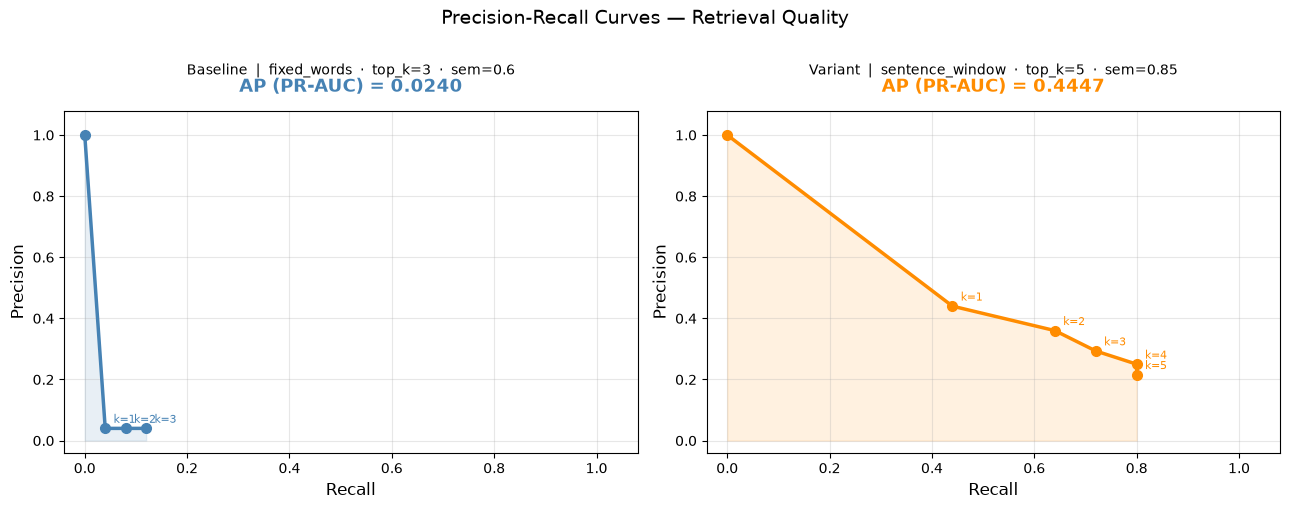

In [13]:
import matplotlib.pyplot as plt
from app.evaluation import build_pr_curve

baseline_label = (
    f"Baseline  |  {config.chunking.active_method}"
    f"  ·  top_k={config.hybrid_search.active_top_k}"
    f"  ·  sem={config.hybrid_search.active_semantic_weight}"
)
variant_label = (
    f"Variant  |  {variant.chunking.active_method}"
    f"  ·  top_k={variant.hybrid_search.active_top_k}"
    f"  ·  sem={variant.hybrid_search.active_semantic_weight}"
)

configs_to_plot = [
    (baseline_label, pipeline,         "steelblue"),
    (variant_label,  variant_pipeline,  "darkorange"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (label, pipe, color) in zip(axes, configs_to_plot):
    recalls, precisions, ap = build_pr_curve(pipe, qa_rows)

    ax.plot(recalls, precisions, marker="o", color=color, linewidth=2.5, markersize=7)
    ax.fill_between(recalls, precisions, alpha=0.12, color=color)

    # AP badge above the chart
    ax.set_title(label, fontsize=10, pad=26)
    ax.text(
        0.5, 1.055, f"AP (PR-AUC) = {ap:.4f}",
        transform=ax.transAxes, ha="center",
        fontsize=13, fontweight="bold", color=color,
    )

    # Rank labels on each point (skip the (0,1) anchor)
    for k, (r, p) in enumerate(zip(recalls[1:], precisions[1:]), start=1):
        ax.annotate(f"k={k}", (r, p), textcoords="offset points",
                    xytext=(6, 4), fontsize=8, color=color)

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_xlim([-0.04, 1.08])
    ax.set_ylim([-0.04, 1.08])
    ax.grid(True, alpha=0.3)

plt.suptitle("Precision-Recall Curves — Retrieval Quality", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
